['J003602.23+295938.3:p1-2', 'J003602.23+295938.3:p1-3', 'J003602.23+295938.3:p1A-1B', 'J022903.99+672408.6:p1-2', 'J022903.99+672408.6:p1-3', 'J022903.99+672408.6:p1-4', 'J022903.99+672408.6:p1-5', 'J022903.99+672408.6:p1-6', 'J022903.99+672408.6:p1-7', 'J022903.99+672408.6:p1-8', 'J022903.99+672408.6:p1-9', 'J022903.99+672408.6:p1A-1B', 'J022903.99+672408.6:p2-3', 'J122635.88-630556.3:p1-2', 'J122635.88-630556.3:p1A-1B', 'J205904.53+041737.7:p1-2', 'J205904.53+041737.7:p1-3', 'J205904.53+041737.7:p1-4', 'J205904.53+041737.7:p1A-1B']


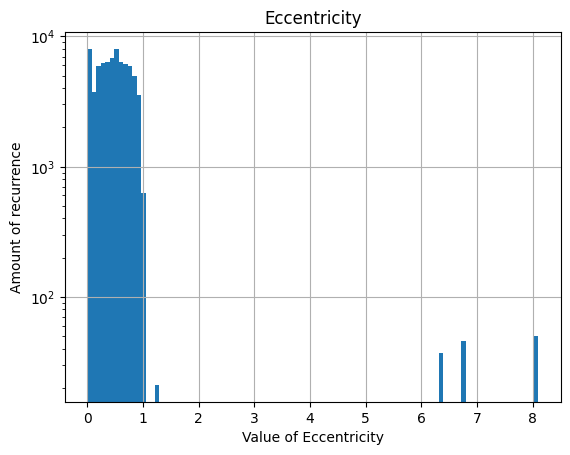

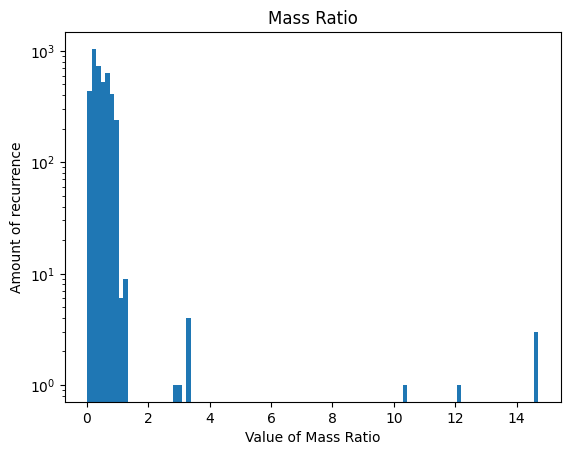

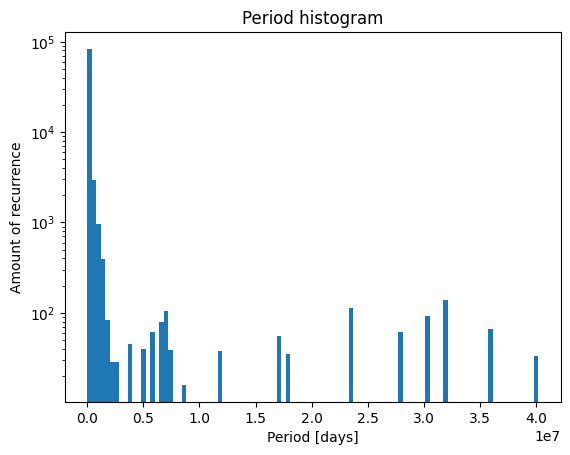

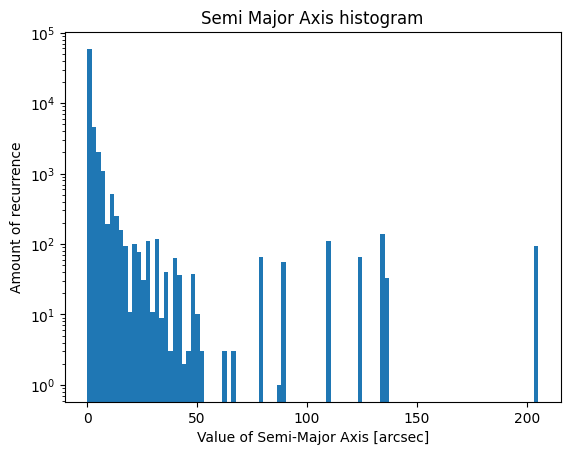

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


df = pd.read_csv(r'DATA/RAW/table2.csv')
eccentricity = df["e"]
mass_ratio = df["q"]
period = df["period"]
semi_major_ax = df["a"]
id = df["bsdb"]
print(df.loc[df['e'] > 1, 'bsdb'].drop_duplicates().to_list())

plt.hist(eccentricity,log=True, bins=100)
plt.xlabel('Value of Eccentricity')
plt.ylabel('Amount of recurrence')
plt.title('Eccentricity')
plt.grid(True)
plt.show()

plt.hist(mass_ratio, log=True, bins=100)
plt.xlabel('Value of Mass Ratio')
plt.ylabel('Amount of recurrence')
plt.title('Mass Ratio')
plt.show()

plt.hist(period, log=True, bins=100)
plt.xlabel('Period [days]')
plt.ylabel('Amount of recurrence')
plt.title('Period histogram')
plt.show()

plt.hist(semi_major_ax, log=True, bins=100)
plt.xlabel('Value of Semi-Major Axis [arcsec]')
plt.ylabel('Amount of recurrence')
plt.title('Semi Major Axis histogram')
plt.show()

In [60]:
df = df.copy()

# Replace eccentricity and mass ratio values > 1 with NaN (instead of dropping rows)
df.loc[df['e'] > 1, 'e'] = np.nan
df.loc[df['q'] > 1, 'q'] = np.nan

# Create cleaned system ID by removing everything after ":"
df['system_id'] = df['bsdb'].astype(str).str.split(':').str[0]

# Columns to average
avg_cols = ['e', 'q', 'period', "a", 'parallax', 'i']

# For each column, replace entries where the value deviates more than 50% from
# the group mean (i.e. relative std > 50%) with NaN, per system_id group
for col in avg_cols:
    group_stats = df.groupby('system_id')[col].transform('std') / \
                  df.groupby('system_id')[col].transform('mean').replace(0, np.nan)
    # Only flag rows that belong to groups with more than 1 valid entry
    group_count = df.groupby('system_id')[col].transform('count')
    high_std_mask = (group_count > 1) & (group_stats.abs() > 0.5)
    df.loc[high_std_mask, col] = np.nan

# Group by system_id, averaging with NaN ignored (pandas default)
reduced_df = (
    df.groupby('system_id', as_index=False)
    .agg({
        'catalogue': lambda x: '; '.join(x.dropna().astype(str).unique()),
        'filename': lambda x: '; '.join(x.dropna().astype(str).unique()),
        "ref_idsys": lambda x: '; '.join(x.dropna().astype(str).unique()),
        "id": lambda x: '; '.join(x.dropna().astype(str).unique()),
        **{col: 'mean' for col in avg_cols}  # pandas mean() skips NaN by default
    })
)

# Combine catalogue + filename into notes column
reduced_df['notes'] = (
        ' | ref_idsys: ' + reduced_df['ref_idsys'].astype(str) +
        ' | id: ' + reduced_df['id'].astype(str) +
        ' | catalogue: ' + reduced_df['catalogue'].astype(str) +
        ' | filename: ' + reduced_df['filename'].astype(str)
)

# Drop temporary columns
reduced_df = reduced_df.drop(columns=['catalogue', 'filename', "ref_idsys","id"])

# Save to CSV
reduced_df.to_csv('DATA/RAW/reduced_raw_data.csv', index=False)

print("Saved as reduced_raw_data.csv")
print(reduced_df.head())

print(
    "Weird issue with some eccentricities being 6.8 and other 0.705 -> looked up the system found that it is 0.705! Looked up another system -> same issue value larger than 1 cannot find anywhere -> will replace all values larger than 1 with NaN, also found for format J022903.99+672408.6:p1-2 everything before : is system specific any changes after still describes same system.")

print("Large standard deviation entries replaced with NaN before averaging — these are excluded from all group means.")


Saved as reduced_raw_data.csv
             system_id      e   q         period        a   parallax       i  \
0  J000001.02-192955.7  0.000 NaN     499.798917  0.01431  20.850000  118.06   
1  J000004.08+341118.8  0.473 NaN     954.500000      NaN        NaN     NaN   
2  J000007.30+184417.0    NaN NaN       2.588993      NaN   1.000000   79.00   
3  J000019.10-441726.0  0.703 NaN  140292.525000  1.02300  13.070769   75.30   
4  J000020.60+605943.0    NaN NaN       9.884258      NaN        NaN     NaN   

                                               notes  
0   | ref_idsys: HD; HIP | id: 224690; 2 | catalo...  
1   | ref_idsys: SBC9 | id: 1707 | catalogue: SB9...  
2   | ref_idsys: GCVS | id: DM Peg | catalogue: J...  
3   | ref_idsys: HD; HIP; WDS | id: 224750; 25; 0...  
4   | ref_idsys: GCVS | id: V654 Cas | catalogue:...  
Weird issue with some eccentricities being 6.8 and other 0.705 -> looked up the system found that it is 0.705! Looked up another system -> same issue value lar

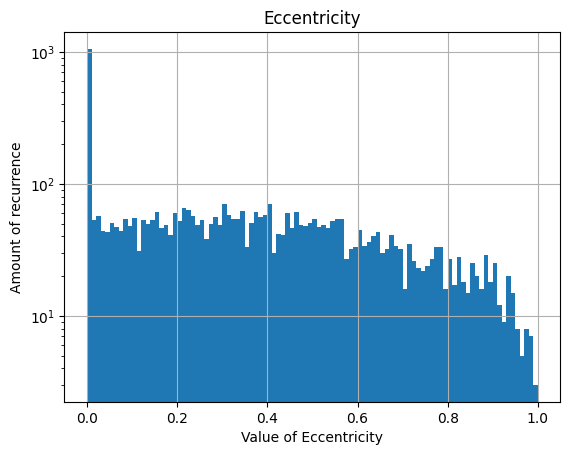

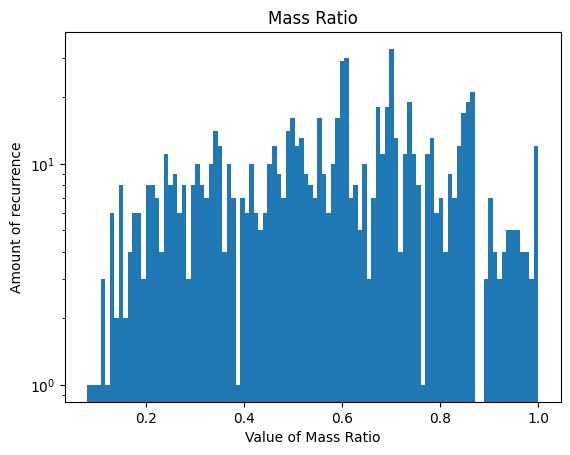

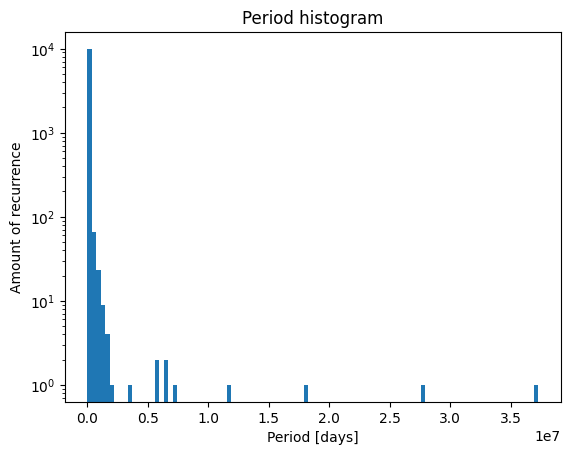

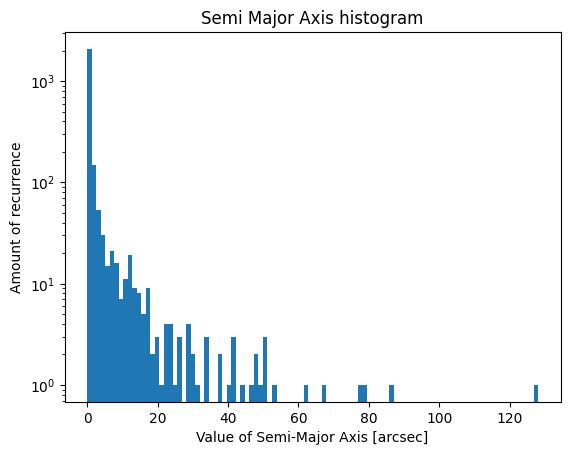

In [63]:
df = pd.read_csv(r'DATA/RAW/reduced_raw_data.csv')
eccentricity = df["e"]
mass_ratio = df["q"]
period = df["period"]
semi_major_ax = df["a"]
id = df["system_id"]

plt.hist(eccentricity, log=True, bins=100)
plt.xlabel('Value of Eccentricity')
plt.ylabel('Amount of recurrence')
plt.title('Eccentricity')
plt.grid(True)
plt.show()

plt.hist(mass_ratio, log=True, bins=100)
plt.xlabel('Value of Mass Ratio')
plt.ylabel('Amount of recurrence')
plt.title('Mass Ratio')
plt.show()

plt.hist(period, log=True, bins=100)
plt.xlabel('Period [days]')
plt.ylabel('Amount of recurrence')
plt.title('Period histogram')
plt.show()

plt.hist(semi_major_ax, log=True, bins=100)
plt.xlabel('Value of Semi-Major Axis [arcsec]')
plt.ylabel('Amount of recurrence')
plt.title('Semi Major Axis histogram')
plt.show()